# Notebook that calculates the WP metric including improvements by boosted metric 

In [ ]:
import os
import pickle

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "-1")

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import tensorflow as tf
import tensorflow.keras as tfk

from warped_metrics import (
    BoostedSpectralPhiModel,
    BoostedSpectralPhiModel_ambient,
    PointGeneratorMathematica,
    PointGeneratorMathematicaIPS,
    SigmaCallback,
    SigmaLoss,
    SpectralFSModelComp,
    VolkCallback,
    build_phi_network,
    calculate_dQdz,
    calculate_ddQdz,
    calc_d_theta_par,
    calc_d_theta_par_ambient,
    compute_weil_petersson,
    configure_tensorflow_runtime,
    holomorphic_volume_form,
    prepare_tf_basis,
    pullbacks,
    train_model,
)

configure_tensorflow_runtime(cpu_only=True)


## load functions required to calculate the WP metric efficiently 

In [ ]:
# some preliminarities

psi = 1.035 - 0.02 * 1.j
monomials = np.array((5 * np.eye(5, dtype=np.int64)).tolist() + [[1, 1, 1, 1, 1]])
coefficients = np.array(np.ones(5).tolist() + [-5 * psi])
kmoduli = np.ones(1)
ambient = np.array([4])
n_fold = 3
nhyper = 1
num_pts = 100000
num_regions = 5
pg = PointGeneratorMathematica([monomials], [coefficients], kmoduli, ambient)

# --- try-invariant precomputation ---
ncoords = n_fold + 2
qI = tf.ones(5, dtype=tf.complex64)

# dQ/dz
obj = calculate_dQdz(ncoords, monomials, coefficients)
dQdz_total = obj._generate_dQdz_basis()
shape = np.array([np.shape(mb) for mb in dQdz_total[0]])
DQDZB = np.zeros((len(shape), np.max(shape[:, 0]), len(shape)), dtype=np.complex64)
DQDZF = np.zeros((len(shape), np.max(shape[:, 0])), dtype=np.complex64)
for i, m in enumerate(zip(dQdz_total[0], dQdz_total[1])):
    DQDZB[i, 0:shape[i, 0]] += m[0]
    DQDZF[i, 0:shape[i, 0]] += m[1]
DQDZB = tf.cast(DQDZB, tf.complex64)
DQDZF = tf.cast(DQDZF, tf.complex64)

# d^2Q/dz^A dz^B
obj = calculate_ddQdz(ncoords, monomials, coefficients)
ddQdz_total = obj.calculate_basis()
shape = np.array([np.shape(mb) for mb in ddQdz_total[0]])
DDQDZB = np.zeros((ncoords, ncoords, np.max(shape[:, 0]), ncoords), dtype=np.complex64)
DDQDZF = np.zeros((ncoords, ncoords, np.max(shape[:, 0])), dtype=np.complex64)
for i, m in enumerate(zip(ddQdz_total[0], ddQdz_total[1])):
    DDQDZB[int(i / ncoords), i % ncoords, 0:shape[i, 0]] += m[0]
    DDQDZF[int(i / ncoords), i % ncoords, 0:shape[i, 0]] += m[1]
DDQDZB = tf.cast(DDQDZB, tf.complex64)
DDQDZF = tf.cast(DDQDZF, tf.complex64)


## learn CY metric for all datasets 

In [ ]:
psi = 1.035 - 0.02 * 1.j
monomials = np.array((5 * np.eye(5, dtype=np.int64)).tolist() + [[1,1,1,1,1]])
coefficients = np.array(np.ones(5).tolist() + [-5 * psi])
kmoduli = np.ones(1)
ambient = np.array([4])
n_fold = 3
num_pts = 100000
num_regions = 5

deg = 2
nlayer = 3
nHidden = 64
n_in = 2 * (BoostedSpectralPhiModel.get_num_sections(n_fold + 2, deg))**2
n_out = 1
act = "gelu"
nEpochs = 50
bSizes = [64, 20000]
alpha = [1., 1., 1., 1., 1.]

test_metrics = [SigmaLoss()]

base_dir = "IPS"

for n_try in range(10):
    pg = PointGeneratorMathematicaIPS([monomials], [coefficients], kmoduli, ambient)

    dirname = os.path.join(base_dir,"points_quintic_{:}_{:}_{:}".format(psi, num_pts, n_try))
    if not os.path.exists(os.path.join(dirname, 'basis.pickle')):
        kappas = pg.prepare_dataset(num_pts, dirname)
        pg.prepare_basis(dirname, kappas)

    data = np.load(os.path.join(dirname, 'dataset.npz'))
    BASIS = np.load(os.path.join(dirname, 'basis.pickle'), allow_pickle=True)
    BASIS = prepare_tf_basis(BASIS)
    new_basis = {}
    for key in BASIS:
        new_basis[key] = tf.cast(BASIS[key], dtype=tf.complex64)
    BASIS = new_basis

    
    # ---- cheaper callback validation subset ----
    Xv, yv = data["X_val"], data["y_val"]
    val_cb_n = min(len(Xv), 5000)
    cb_data = (Xv[:val_cb_n], yv[:val_cb_n])

    scb = SigmaCallback(cb_data)
    volkcb = VolkCallback(cb_data)
    cb_list = [scb, volkcb]
    
    # ---- build model ----
    nn_phi_1 = tf.keras.Sequential()
    nn_phi_1.add(tfk.Input(shape=(n_in,)))
    for _ in range(nlayer):
        nn_phi_1.add(tfk.layers.Dense(nHidden, activation=act))
    # dtype float32 to be safe with mixed precision
    nn_phi_1.add(tfk.layers.Dense(n_out, use_bias=False, dtype="float32"))

    model_path = os.path.join(dirname, "nn_phi_1.keras")
    hist_path  = os.path.join(dirname, "training_history_1.pickle")

    phimodel = BoostedSpectralPhiModel([nn_phi_1], BASIS, alpha=alpha, deg=[deg], monomials=monomials)

    # optimizer (simple + fast)
    opt_phi = tfk.optimizers.Adam(learning_rate=1e-3)

    if not os.path.exists(model_path):
        # optional: reduce verbosity for speed
        phimodel, training_history = train_model(
            phimodel,
            data,
            optimizer=opt_phi,
            epochs=nEpochs,
            batch_sizes=bSizes,
            verbose=1,
            custom_metrics=test_metrics,
            callbacks=cb_list,
        )
        nn_phi_1 = phimodel.models[-1]
        nn_phi_1.save(model_path)
        with open(hist_path, "wb") as f:
            pickle.dump(training_history, f)

    nn_phi_1 = tf.keras.models.load_model(model_path, compile=False)
    nn_phi_1.trainable = True
    _ = nn_phi_1(tf.zeros((1, n_in), dtype=tf.float32))

    with open(hist_path, "rb") as f:
        training_history_1 = pickle.load(f)


## same for second step

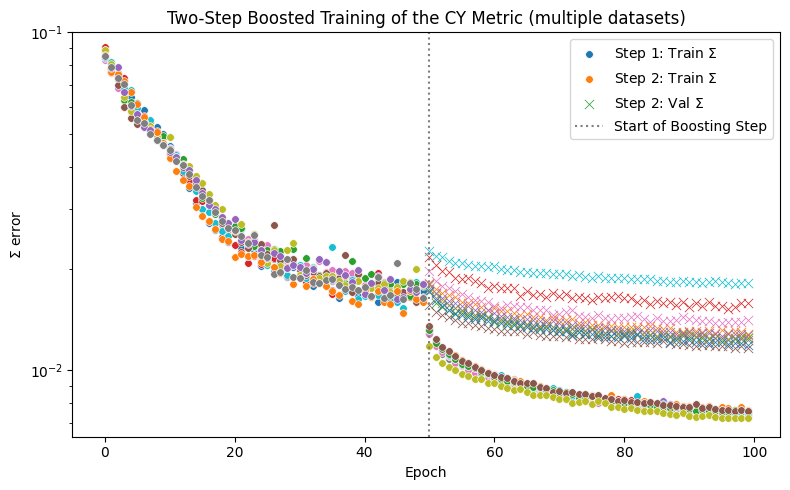

In [ ]:
# need smaller batch sizes with two NN to not crash the kernel.
bSizes = [64, 20000]

# ---- ONE FIGURE for all tries ----
plt.figure(figsize=(8, 5))

transition_x = None  # set once from per-try history_1 length (assumed constant across tries)

for i, n_try in enumerate(range(10)):
    pg = PointGeneratorMathematica([monomials], [coefficients], kmoduli, ambient)

    dirname = os.path.join(base_dir, "points_quintic_{:}_{:}_{:}".format(psi, num_pts, n_try))

    # --- prepare dataset/basis if needed ---
    if not os.path.exists(os.path.join(dirname, 'basis.pickle')):
        kappas = pg.prepare_dataset(num_pts, dirname)
        pg.prepare_basis(dirname, kappas)

    data = np.load(os.path.join(dirname, 'dataset.npz'))
    BASIS = np.load(os.path.join(dirname, 'basis.pickle'), allow_pickle=True)
    BASIS = prepare_tf_basis(BASIS)
    BASIS = {k: tf.cast(BASIS[k], dtype=tf.complex64) for k in BASIS}

    # ---- cheaper callback validation subset ----
    Xv, yv = data["X_val"], data["y_val"]
    val_cb_n = min(len(Xv), 5000)
    cb_data = (Xv[:val_cb_n], yv[:val_cb_n])

    scb = SigmaCallback(cb_data)
    volkcb = VolkCallback(cb_data)
    cb_list = [scb, volkcb]

    # ---- Load per-try histories ----
    hist1_path = os.path.join(dirname, "training_history_1.pickle")
    if not os.path.exists(hist1_path):
        raise FileNotFoundError(
            f"Missing step-1 history for n_try={n_try}: {hist1_path}\n"
            "If step-1 was saved elsewhere, point hist1_path to that location."
        )

    with open(hist1_path, "rb") as f:
        training_history_1 = pickle.load(f)

    phi2_path  = os.path.join(dirname, "nn_phi_2.keras")
    hist2_path = os.path.join(dirname, "training_history_2.pickle")

    # ---- Load or train phi_2 (phi_1 assumed already trained/saved per-try too) ----
    # If your phi_1 is also per-try, use: phi1_path = os.path.join(dirname, "nn_phi_1.keras")
    # Here I assume global model_path is OK; change if needed.
    nn_phi_1 = tf.keras.models.load_model(model_path, compile=False)
    nn_phi_1.trainable = True
    _ = nn_phi_1(tf.zeros((1, n_in), dtype=tf.float32))

    if os.path.exists(phi2_path):
        nn_phi_2 = tf.keras.models.load_model(phi2_path, compile=False)
    else:
        nn_phi_2 = build_phi_network(n_in, nlayer, nHidden, act, n_out=n_out, mixed_precision_safe=True)
        _ = nn_phi_2(tf.zeros((1, n_in), dtype=tf.float32))
        nn_phi_2.set_weights(nn_phi_1.get_weights())

        phimodel_2_tmp = BoostedSpectralPhiModel([nn_phi_1, nn_phi_2], BASIS, alpha=alpha, deg=[deg], monomials=monomials)

        opt_phi = tfk.optimizers.Adam(learning_rate=1e-3)
        phimodel_2_tmp, training_history_2 = train_model(
            phimodel_2_tmp,
            data,
            optimizer=opt_phi,
            epochs=nEpochs,
            batch_sizes=bSizes,
            verbose=1,
            custom_metrics=test_metrics,
            callbacks=cb_list,
        )

        nn_phi_2 = phimodel_2_tmp.models[-1]
        nn_phi_2.save(phi2_path)
        with open(hist2_path, "wb") as f:
            pickle.dump(training_history_2, f)

    # load step-2 history
    if not os.path.exists(hist2_path):
        raise FileNotFoundError(f"Missing step-2 history for n_try={n_try}: {hist2_path}")
    with open(hist2_path, "rb") as f:
        training_history_2 = pickle.load(f)

    # ---- Extract curves ----
    sigma_loss_1 = np.array(training_history_1["sigma_loss"])
    sigma_loss_2 = np.array(training_history_2["sigma_loss"])
    sigma_val_2  = np.array(training_history_2["sigma_val"])

    epochs_1 = np.arange(len(sigma_loss_1))
    epochs_2 = np.arange(len(sigma_loss_1), len(sigma_loss_1) + len(sigma_loss_2))

    if transition_x is None:
        transition_x = len(sigma_loss_1)

    # Labels only once (avoid legend spam)
    label_step1 = r"Step 1: Train $\sigma$" if i == 0 else None
    label_step2 = r"Step 2: Train $\sigma$" if i == 0 else None
    label_val2  = r"Step 2: Val $\sigma$"   if i == 0 else None

    # Scatter only; mild transparency helps overplotting
    sns.scatterplot(x=epochs_1, y=sigma_loss_1, s=30, alpha=1, label=label_step1)
    sns.scatterplot(x=epochs_2, y=sigma_loss_2, s=30, alpha=1, label=label_step2)
    sns.scatterplot(x=epochs_2, y=sigma_val_2,  s=45, alpha=1, marker="x", label=label_val2)

# Transition line once
plt.axvline(transition_x, color="gray", linestyle=":", linewidth=1.5, label="Start of Boosting Step")

plt.yscale("log")
plt.ylim(top=1e-1)
plt.xlabel("Epoch")
plt.ylabel(r"$\sigma$ error")
plt.title("Two-Step Boosted Training of the CY Metric (multiple datasets)")
plt.legend()
plt.tight_layout()

plt.savefig("cy_metric_two_step_training_sigma_all_tries.pdf", bbox_inches="tight", dpi=300)
plt.show()


# Calculate WP metric for all different metrics

In [ ]:
# some preliminarities

psi = 1.035 - 0.02 * 1.j
monomials = np.array((5 * np.eye(5, dtype=np.int64)).tolist() + [[1, 1, 1, 1, 1]])
coefficients = np.array(np.ones(5).tolist() + [-5 * psi])
kmoduli = np.ones(1)
ambient = np.array([4])
n_fold = 3
nhyper = 1
num_pts = 100000
num_regions = 5
pg = PointGeneratorMathematica([monomials], [coefficients], kmoduli, ambient)

# --- try-invariant precomputation ---
ncoords = n_fold + 2
qI = tf.ones(5, dtype=tf.complex64)

# dQ/dz
obj = calculate_dQdz(ncoords, monomials, coefficients)
dQdz_total = obj._generate_dQdz_basis()
shape = np.array([np.shape(mb) for mb in dQdz_total[0]])
DQDZB = np.zeros((len(shape), np.max(shape[:, 0]), len(shape)), dtype=np.complex64)
DQDZF = np.zeros((len(shape), np.max(shape[:, 0])), dtype=np.complex64)
for i, m in enumerate(zip(dQdz_total[0], dQdz_total[1])):
    DQDZB[i, 0:shape[i, 0]] += m[0]
    DQDZF[i, 0:shape[i, 0]] += m[1]
DQDZB = tf.cast(DQDZB, tf.complex64)
DQDZF = tf.cast(DQDZF, tf.complex64)

# d^2Q/dz^A dz^B
obj = calculate_ddQdz(ncoords, monomials, coefficients)
dDQdz_total = obj.calculate_basis()
shape = np.array([np.shape(mb) for mb in dDQdz_total[0]])
DDQDZB = np.zeros((ncoords, ncoords, np.max(shape[:, 0]), ncoords), dtype=np.complex64)
DDQDZF = np.zeros((ncoords, ncoords, np.max(shape[:, 0])), dtype=np.complex64)
for i, m in enumerate(zip(dDQdz_total[0], dDQdz_total[1])):
    DDQDZB[int(i / ncoords), i % ncoords, 0:shape[i, 0]] += m[0]
    DDQDZF[int(i / ncoords), i % ncoords, 0:shape[i, 0]] += m[1]
DDQDZB = tf.cast(DDQDZB, tf.complex64)
DDQDZF = tf.cast(DDQDZF, tf.complex64)


In [ ]:
# insert the data here

WPs_FS = []
WPs_phi1 = [] 
WPs_phi2 = []

base_dir = "IPS"

for n_try in range(10):

    dirname = os.path.join(base_dir,"points_quintic_ips_{:}_{:}_{:}".format(psi, num_pts, n_try))
    if not os.path.exists(os.path.join(dirname, 'basis.pickle')):
        kappas = pg.prepare_dataset(num_pts, dirname)
        pg.prepare_basis(dirname, kappas)

    data = np.load(os.path.join(dirname, 'dataset.npz'))
    BASIS = np.load(os.path.join(dirname, 'basis.pickle'), allow_pickle=True)
    BASIS = prepare_tf_basis(BASIS)
    new_basis = {}
    for key in BASIS:
        new_basis[key] = tf.cast(BASIS[key], dtype=tf.complex64)
    BASIS = new_basis

    #precalculations, needed to get WP metric 
    pts = tf.cast(np.concatenate([data["X_train"], data["X_val"]], axis=0), dtype=tf.float32)
    wo = np.concatenate([data["y_train"], data["y_val"]], axis=0)
    points = tf.cast(tf.complex(pts[:, 0:ncoords] , pts[:, ncoords:]),dtype=tf.complex64)
    max_dQ_coord = pg._find_max_dQ_coords(points)                 # typically numpy (N, nhyper)
    max_dQ_coord = tf.convert_to_tensor(max_dQ_coord[:, 0], tf.int32)  # (N,)
    # pullback
    pbs = pullbacks(pg, points, j_elim=None)
    omega = holomorphic_volume_form(pg, points)

    comp_model = SpectralFSModelComp(None, BASIS, alpha=[1.], deg=2, monomials=monomials)

    tfpts = tf.cast(pts, dtype=tf.float32)

    # --- d_thetas cache ---
    filepath = os.path.join(dirname, "d_thetas.npz")
    d_thetas = calc_d_theta_par(
        target_file=filepath,
        pts=tfpts,
        DQDZB=DQDZB, DQDZF=DQDZF,
        DDQDZB=DDQDZB, DDQDZF=DDQDZF,
        qI=qI, ncoords=ncoords,
        comp_model=comp_model,
        pg=pg,
        batch_size=10000,
    )

    WP = compute_weil_petersson(
        d_thetas=d_thetas,
        pb=pbs,
        omega=omega,
        weights=wo[:, 0],
        max_dQ_coords=max_dQ_coord,
        points=points,
    )
    print("WP:", WP)
    WPs_FS = tf.concat([WPs_FS, [WP]], axis=0)

    #same for phi1: 

    phimodel_amb = BoostedSpectralPhiModel_ambient([nn_phi_1], BASIS, alpha=alpha, deg=[deg], monomials=monomials)

    # --- d_thetas cache ---
    filepath = os.path.join(dirname, "d_thetas_improved_phi1.npz")
    d_thetas = calc_d_theta_par_ambient(
        target_file=filepath,
        pts=tfpts,
        DQDZB=DQDZB, DQDZF=DQDZF,
        DDQDZB=DDQDZB, DDQDZF=DDQDZF,
        qI=qI, ncoords=ncoords,
        metric_model=phimodel_amb,
        pg=pg,
        batch_size=10000,
    )

    WP = compute_weil_petersson(
        d_thetas=d_thetas,
        pb=pbs,
        omega=omega,
        weights=wo[:, 0],
        max_dQ_coords=max_dQ_coord,
        points=points,
    )
    print("WP:", WP)
    WPs_phi1 = tf.concat([WPs_phi1, [WP]], axis=0)

    # same for phi2:

    phimodel_2 = BoostedSpectralPhiModel_ambient([nn_phi_1, nn_phi_2], BASIS, alpha=alpha, deg=[deg], monomials=monomials)

    # --- d_thetas cache ---
    filepath = os.path.join(dirname, "d_thetas_improved_phi2.npz")
    d_thetas = calc_d_theta_par_ambient(
        target_file=filepath,
        pts=tfpts,
        DQDZB=DQDZB, DQDZF=DQDZF,
        DDQDZB=DDQDZB, DDQDZF=DDQDZF,
        qI=qI, ncoords=ncoords,
        metric_model=phimodel_2,
        pg=pg,
        batch_size=10000,
    )

    WP = compute_weil_petersson(
        d_thetas=d_thetas,
        pb=pbs,
        omega=omega,
        weights=wo[:, 0],
        max_dQ_coords=max_dQ_coord,
        points=points,
    )
    print("WP:", WP)
    WPs_phi2 = tf.concat([WPs_phi2, [WP]], axis=0)


WP: tf.Tensor((0.15321653+0j), shape=(), dtype=complex64)
WP: tf.Tensor((0.1599196+0j), shape=(), dtype=complex64)
WP: tf.Tensor((0.15995413+0j), shape=(), dtype=complex64)
WP: tf.Tensor((0.16532014+0j), shape=(), dtype=complex64)
WP: tf.Tensor((0.17060225+0j), shape=(), dtype=complex64)
WP: tf.Tensor((0.1702743+0j), shape=(), dtype=complex64)
WP: tf.Tensor((0.20222074+0j), shape=(), dtype=complex64)
WP: tf.Tensor((0.20021245+0j), shape=(), dtype=complex64)
WP: tf.Tensor((0.20023592+0j), shape=(), dtype=complex64)
WP: tf.Tensor((0.2083507+0j), shape=(), dtype=complex64)
WP: tf.Tensor((0.20790792+0j), shape=(), dtype=complex64)
WP: tf.Tensor((0.20828773+0j), shape=(), dtype=complex64)
WP: tf.Tensor((0.194936+0j), shape=(), dtype=complex64)
WP: tf.Tensor((0.19903626+0j), shape=(), dtype=complex64)
WP: tf.Tensor((0.199118+0j), shape=(), dtype=complex64)
WP: tf.Tensor((0.1863664+0j), shape=(), dtype=complex64)
WP: tf.Tensor((0.18758836+0j), shape=(), dtype=complex64)
WP: tf.Tensor((0.18724

WP FS mean =  tf.Tensor(0.1833444, shape=(), dtype=float32)
WP phi1 mean =  tf.Tensor(0.18714376, shape=(), dtype=float32)
WP phi2 mean =  tf.Tensor(0.18710911, shape=(), dtype=float32)


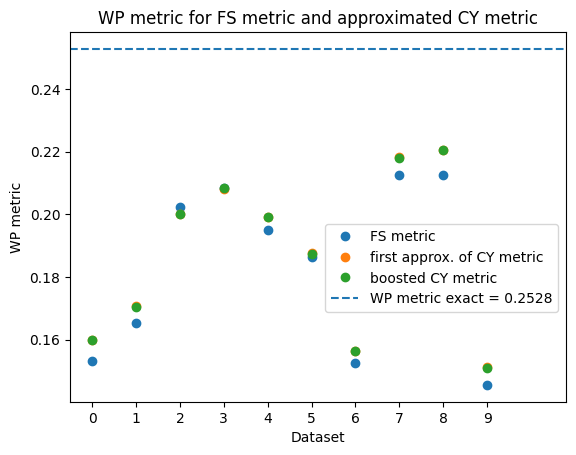

In [ ]:
print('WP FS mean = ', tf.reduce_mean(WPs_FS))
print('WP phi1 mean = ', tf.reduce_mean(WPs_phi1))
print('WP phi2 mean = ', tf.reduce_mean(WPs_phi2))

WP_exact = 0.2528  
x = range(10)
plt.plot(x, WPs_FS,   marker='o', linestyle='None', label="FS metric")
plt.plot(x, WPs_phi1, marker='o', linestyle='None', label="first approx. of CY metric")
plt.plot(x, WPs_phi2, marker='o', linestyle='None', label="boosted CY metric")

plt.axhline(y=WP_exact, linestyle='--', label=f"WP metric exact = {WP_exact:.4f}")

plt.xticks(range(10))        # 0,1,2,...,11

plt.xlim(-0.5, 10.8)

plt.legend(
    loc="upper left",
    bbox_to_anchor=(0.5, 0.5)
)
plt.xlabel("Dataset")
plt.ylabel("WP metric")
plt.title("WP metric for FS metric and approximated CY metric")

plt.savefig("WP_metric_comparison_away_IPS.pdf", bbox_inches="tight")

plt.show()

the same calculation can be done for all other datasets/sampling methods 